# Diabetes Prediction System
## Dataset: Kaggle Diabetes Dataset
### Columns: gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level, diabetes
### Model: Logistic Regression voi model.fit()

## Bước 1: Khai báo thư viện và tải dữ liệu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# Thiết lập Random Seed cố định để đảm bảo tính tái lập (Reproducibility)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 1. Đọc dữ liệu thô từ file CSV
df = pd.read_csv('../../DATA/diabetes.csv')

print("="*60)
print(f"📊 KÍCH THƯỚC TẬP DỮ LIỆU BAN ĐẦU: {df.shape[0]} dòng, {df.shape[1]} cột")
print("="*60)
df.head()

## Bước 2: Kiểm tra chất lượng dữ liệu và làm sạch

In [2]:
print("1. THÔNG TIN KIỂU DỮ LIỆU VÀ CẤU TRÚC:")
print(df.info())

print("\n2. KIỂM TRA GIÁ TRỊ KHUYẾT (MISSING VALUES):")
print(df.isna().sum())

print("\n3. KIỂM TRA DÒNG TRÙNG LẶP (DUPLICATES):")
duplicate_count = df.duplicated().sum()
print(f"Số lượng bản ghi trùng lặp: {duplicate_count}")

# Xử lý làm sạch dữ liệu:
# - Loại bỏ các dòng trùng lặp hoàn toàn
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"-> Đã xóa {duplicate_count} dòng trùng lặp.")

# - Xử lý giá trị bất thường: Loại bỏ các bản ghi mang nhãn 'Other' ở cột gender vì số lượng quá nhỏ
df = df[df['gender'] != 'Other'].reset_index(drop=True)

print(f"\n4. KÍCH THƯỚC DỮ LIỆU SAU KHI LÀM SẠCH: {df.shape[0]} dòng, {df.shape[1]} cột")

print("\n5. PHÂN PHỐI BIẾN MỤC TIÊU (CLASS DISTRIBUTION):")
class_counts = df['diabetes'].value_counts()
class_percentages = df['diabetes'].value_counts(normalize=True) * 100
print(f"Lớp 0 (Âm tính) : {class_counts[0]} mẫu ({class_percentages[0]:.2f}%)")
print(f"Lớp 1 (Dương tính): {class_counts[1]} mẫu ({class_percentages[1]:.2f}%)")

1. THÔNG TIN KIỂU DỮ LIỆU VÀ CẤU TRÚC:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB
None

2. KIỂM TRA GIÁ TRỊ KHUYẾT (MISSING VALUES):
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_leve

## Bước 3: Biểu diễn dữ liệu số học (Vector, Ma trận & Tensor)

In [3]:
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Kiểm tra và import torch (nếu chưa có thì dùng numpy để biểu diễn tensor đa chiều)
try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

# --- 1. MÃ HÓA BIẾN PHÂN LOẠI (CATEGORICAL ENCODING) ---
categorical_cols = ['gender', 'smoking_history']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Tách biến độc lập (X) và biến mục tiêu (y)
X = df_encoded.drop(columns=['diabetes'])
y = df_encoded['diabetes']

# --- 2. BIỂU DIỄN DƯỚI DẠNG VECTOR, MA TRẬN VÀ TENSOR ---
# A. Vector của 1 quan sát mẫu x_1 in R^d
sample_vector = X.iloc[0].to_numpy(dtype=np.float32)

# B. Ma trận đặc trưng toàn phần (Feature Matrix X) in R^(N x d)
feature_matrix = X.to_numpy(dtype=np.float32)
target_vector = y.to_numpy(dtype=np.int64)

# C. Biểu diễn Tensor
if HAS_TORCH:
    tensor_X = torch.tensor(feature_matrix, dtype=torch.float32)
    tensor_y = torch.tensor(target_vector, dtype=torch.long)
    tensor_type_str = f"PyTorch Tensor (X: {tensor_X.shape}, y: {tensor_y.shape})"
else:
    # NumPy ndarray là biểu diễn Tensor tiêu chuẩn của Scikit-Learn
    tensor_X = np.asarray(feature_matrix, dtype=np.float32)
    tensor_y = np.asarray(target_vector, dtype=np.int64)
    tensor_type_str = f"NumPy Tensor/NDArray (X: {tensor_X.shape}, y: {tensor_y.shape})"

print("="*75)
print("📐 ĐO LƯỜNG VÀ BIỂU DIỄN DỮ LIỆU SỐ HỌC (DATA REPRESENTATION):")
print(f"1. Vector của một quan sát mẫu (x_1) in R^{len(sample_vector)}:")
print(f"   Shape: {sample_vector.shape} -> Giá trị:\n   {sample_vector}")
print(f"\n2. Ma trận đặc trưng toàn phần (Feature Matrix X) in R^(N x d):")
print(f"   Shape: {feature_matrix.shape} (N={feature_matrix.shape[0]} mẫu, d={feature_matrix.shape[1]} đặc trưng)")
print(f"\n3. Biểu diễn Tensor tính toán:")
print(f"   {tensor_type_str}")
print("="*75)

# Lưu danh sách tên cột để Flask API map đúng thứ tự đặc trưng
with open('diabetes_model_columns.json', 'w', encoding='utf-8') as f:
    json.dump(list(X.columns), f, ensure_ascii=False)

# --- 3. CHIA TẬP TRAIN/TEST (CHỐNG DATA LEAKAGE) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# --- 4. CHUẨN HÓA DỮ LIỆU (Z-SCORE SCALING) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lưu bộ chuẩn hóa
joblib.dump(scaler, 'scaler_diabetes.pkl')

print("\n📊 KÍCH THƯỚC MA TRẬN ĐẦU VÀO SAU CHUẨN HÓA (MODEL INPUT):")
print(f"- Ma trận Train sau Scaling : {X_train_scaled.shape}")
print(f"- Ma trận Test sau Scaling  : {X_test_scaled.shape}")
print(f"- Mean của cột 0 trên Train : {X_train_scaled[:, 0].mean():.4f} (Gần bằng 0)")
print(f"- Std của cột 0 trên Train  : {X_train_scaled[:, 0].std():.4f} (Bằng 1)")
print("="*75)

📐 ĐO LƯỜNG VÀ BIỂU DIỄN DỮ LIỆU SỐ HỌC (DATA REPRESENTATION):
1. Vector của một quan sát mẫu (x_1) in R^12:
   Shape: (12,) -> Giá trị:
   [ 80.     0.     1.    25.19   6.6  140.     0.     0.     0.     0.
   1.     0.  ]

2. Ma trận đặc trưng toàn phần (Feature Matrix X) in R^(N x d):
   Shape: (96128, 12) (N=96128 mẫu, d=12 đặc trưng)

3. Biểu diễn Tensor tính toán:
   PyTorch Tensor (X: torch.Size([96128, 12]), y: torch.Size([96128]))

📊 KÍCH THƯỚC MA TRẬN ĐẦU VÀO SAU CHUẨN HÓA (MODEL INPUT):
- Ma trận Train sau Scaling : (76902, 12)
- Ma trận Test sau Scaling  : (19226, 12)
- Mean của cột 0 trên Train : 0.0000 (Gần bằng 0)
- Std của cột 0 trên Train  : 1.0000 (Bằng 1)


## Bước 4: Phân tích và khám phá dữ liệu

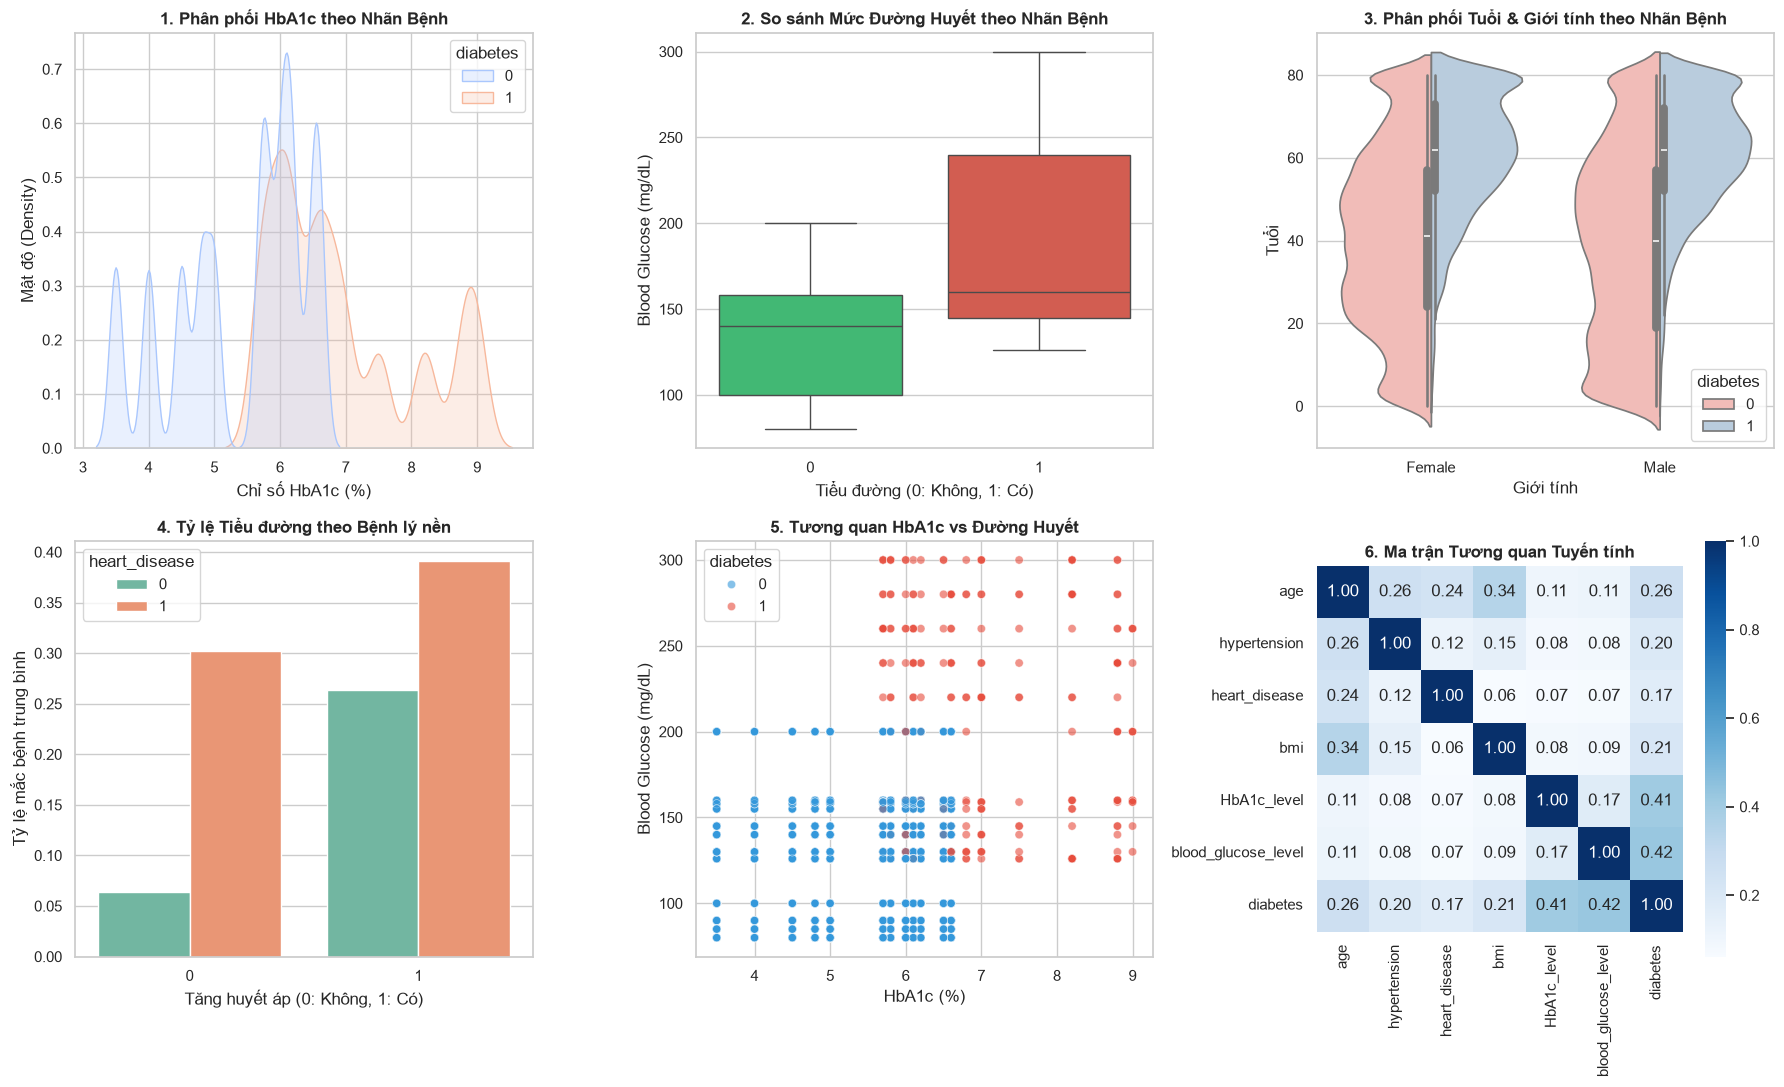

In [4]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Phân phối HbA1c theo nhóm Bệnh / Không bệnh (KDE Plot)
sns.kdeplot(data=df, x='HbA1c_level', hue='diabetes', fill=True, common_norm=False, palette='coolwarm', ax=axes[0, 0])
axes[0, 0].set_title('1. Phân phối HbA1c theo Nhãn Bệnh', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Chỉ số HbA1c (%)')
axes[0, 0].set_ylabel('Mật độ (Density)')

# 2. Phân phối Mức đường huyết theo nhóm Bệnh / Không bệnh (Boxplot)
sns.boxplot(data=df, x='diabetes', y='blood_glucose_level', hue='diabetes', palette=['#2ecc71', '#e74c3c'], ax=axes[0, 1], legend=False)
axes[0, 1].set_title('2. So sánh Mức Đường Huyết theo Nhãn Bệnh', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tiểu đường (0: Không, 1: Có)')
axes[0, 1].set_ylabel('Blood Glucose (mg/dL)')

# 3. Phân phối Tuổi theo Giới tính và Tình trạng Bệnh (Violin Plot)
sns.violinplot(data=df, x='gender', y='age', hue='diabetes', split=True, palette='Pastel1', ax=axes[0, 2])
axes[0, 2].set_title('3. Phân phối Tuổi & Giới tính theo Nhãn Bệnh', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Giới tính')
axes[0, 2].set_ylabel('Tuổi')

# 4. Tỷ lệ mắc bệnh theo Tiền sử Tăng huyết áp & Tim mạch (Barplot)
sns.barplot(data=df, x='hypertension', y='diabetes', hue='heart_disease', palette='Set2', errorbar=None, ax=axes[1, 0])
axes[1, 0].set_title('4. Tỷ lệ Tiểu đường theo Bệnh lý nền', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tăng huyết áp (0: Không, 1: Có)')
axes[1, 0].set_ylabel('Tỷ lệ mắc bệnh trung bình')

# 5. Mối quan hệ giữa HbA1c và Đường huyết (Scatter Plot)
sample_df = df.sample(n=min(3000, len(df)), random_state=RANDOM_SEED)
sns.scatterplot(data=sample_df, x='HbA1c_level', y='blood_glucose_level', hue='diabetes', alpha=0.6, palette=['#3498db', '#e74c3c'], ax=axes[1, 1])
axes[1, 1].set_title('5. Tương quan HbA1c vs Đường Huyết', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('HbA1c (%)')
axes[1, 1].set_ylabel('Blood Glucose (mg/dL)')

# 6. Ma trận tương quan giữa các biến định lượng (Heatmap)
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues', cbar=True, square=True, ax=axes[1, 2])
axes[1, 2].set_title('6. Ma trận Tương quan Tuyến tính', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Bước 5: Phân chia tập dữ liệu và chuẩn hóa thang đo

In [5]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Phân chia Train/Test 80%/20% có phân tầng nhãn (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

# 2. Chuẩn hóa Z-score (Chỉ fit trên X_train để chống rò rỉ dữ liệu - Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Lưu bộ tham số chuẩn hóa
joblib.dump(scaler, 'scaler_diabetes.pkl')

print("="*75)
print("📊 KÍCH THƯỚC MA TRẬN ĐẦU VÀO SAU CHUẨN HÓA (MODEL INPUT):")
print(f"- Ma trận Train sau Scaling : {X_train_scaled.shape}")
print(f"- Ma trận Test sau Scaling  : {X_test_scaled.shape}")
print(f"- Mean của cột 0 trên Train : {X_train_scaled[:, 0].mean():.4f} (Gần bằng 0)")
print(f"- Std của cột 0 trên Train  : {X_train_scaled[:, 0].std():.4f} (Bằng 1)")
print("📁 Đã lưu bộ chuẩn hóa: 'scaler_diabetes.pkl'")
print("="*75)

📊 KÍCH THƯỚC MA TRẬN ĐẦU VÀO SAU CHUẨN HÓA (MODEL INPUT):
- Ma trận Train sau Scaling : (76902, 12)
- Ma trận Test sau Scaling  : (19226, 12)
- Mean của cột 0 trên Train : 0.0000 (Gần bằng 0)
- Std của cột 0 trên Train  : 1.0000 (Bằng 1)
📁 Đã lưu bộ chuẩn hóa: 'scaler_diabetes.pkl'


## Bước 6: Huấn luyện 5 mô hình và đánh giá 5 độ đo

In [6]:
# Tạo danh sách để lưu kết quả đánh giá của từng model
results = []
trained_models = {}
print("✅ Sẵn sàng huấn luyện các mô hình!")

✅ Sẵn sàng huấn luyện các mô hình!


### Mô hình 1: K-Nearest Neighbors (KNN)
(KNN dựa trên khoảng cách hình học nên sử dụng tập dữ liệu đã chuẩn hóa X_train_scaled, X_test_scaled)

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("⏳ [1/5] Đang huấn luyện mô hình KNN (vui lòng đợi khoảng 30s - 1 phút)...")

# 1. Huấn luyện
knn_model = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)

# 2. Dự đoán
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# 3. Tính toán 5 độ đo
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, zero_division=0)
rec_knn = recall_score(y_test, y_pred_knn, zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, zero_division=0)
auc_knn = roc_auc_score(y_test, y_prob_knn)

# Lưu kết quả
trained_models["K-Nearest Neighbors (KNN)"] = knn_model
results.append({
    "Model": "K-Nearest Neighbors (KNN)",
    "Accuracy": round(acc_knn, 4),
    "Precision": round(prec_knn, 4),
    "Recall": round(rec_knn, 4),
    "F1-Score": round(f1_knn, 4),
    "ROC-AUC": round(auc_knn, 4)
})

# In chi tiết kết quả
print("\n" + "="*50)
print("🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: K-Nearest Neighbors (KNN)")
print("="*50)
print(f"1. Accuracy  (Độ chính xác) : {acc_knn:.4f} ({acc_knn*100:.2f}%)")
print(f"2. Precision (Độ chuẩn xác) : {prec_knn:.4f} ({prec_knn*100:.2f}%)")
print(f"3. Recall    (Độ nhạy)      : {rec_knn:.4f} ({rec_knn*100:.2f}%)")
print(f"4. F1-Score  (Điểm F1)      : {f1_knn:.4f}")
print(f"5. ROC-AUC   (Diện tích ROC): {auc_knn:.4f}")
print("\n--- Ma trận nhầm lẫn (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_knn))
print("="*50)

⏳ [1/5] Đang huấn luyện mô hình KNN (vui lòng đợi khoảng 30s - 1 phút)...

🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: K-Nearest Neighbors (KNN)
1. Accuracy  (Độ chính xác) : 0.9589 (95.89%)
2. Precision (Độ chuẩn xác) : 0.9002 (90.02%)
3. Recall    (Độ nhạy)      : 0.6008 (60.08%)
4. F1-Score  (Điểm F1)      : 0.7207
5. ROC-AUC   (Diện tích ROC): 0.9142

--- Ma trận nhầm lẫn (Confusion Matrix) ---
[[17417   113]
 [  677  1019]]


### Mô hình 2: Logistic Regression
(Sử dụng dữ liệu đã chuẩn hóa X_train_scaled để mô hình hội tụ nhanh và tối ưu)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("⏳ [2/5] Đang huấn luyện mô hình Logistic Regression...")

# 1. Huấn luyện
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 2. Dự đoán
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# 3. Tính toán 5 độ đo
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Lưu kết quả
trained_models["Logistic Regression"] = lr_model
results.append({
    "Model": "Logistic Regression",
    "Accuracy": round(acc_lr, 4),
    "Precision": round(prec_lr, 4),
    "Recall": round(rec_lr, 4),
    "F1-Score": round(f1_lr, 4),
    "ROC-AUC": round(auc_lr, 4)
})

# In chi tiết kết quả
print("\n" + "="*50)
print("🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Logistic Regression")
print("="*50)
print(f"1. Accuracy  (Độ chính xác) : {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"2. Precision (Độ chuẩn xác) : {prec_lr:.4f} ({prec_lr*100:.2f}%)")
print(f"3. Recall    (Độ nhạy)      : {rec_lr:.4f} ({rec_lr*100:.2f}%)")
print(f"4. F1-Score  (Điểm F1)      : {f1_lr:.4f}")
print(f"5. ROC-AUC   (Diện tích ROC): {auc_lr:.4f}")
print("\n--- Ma trận nhầm lẫn (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_lr))
print("="*50)

⏳ [2/5] Đang huấn luyện mô hình Logistic Regression...

🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Logistic Regression
1. Accuracy  (Độ chính xác) : 0.9589 (95.89%)
2. Precision (Độ chuẩn xác) : 0.8601 (86.01%)
3. Recall    (Độ nhạy)      : 0.6380 (63.80%)
4. F1-Score  (Điểm F1)      : 0.7326
5. ROC-AUC   (Diện tích ROC): 0.9596

--- Ma trận nhầm lẫn (Confusion Matrix) ---
[[17354   176]
 [  614  1082]]


### Mô hình 3: Decision Tree

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("⏳ [3/5] Đang huấn luyện mô hình Decision Tree...")

# 1. Huấn luyện
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

# 2. Dự đoán
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# 3. Tính toán 5 độ đo
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)
auc_dt = roc_auc_score(y_test, y_prob_dt)

# Lưu kết quả
trained_models["Decision Tree"] = dt_model
results.append({
    "Model": "Decision Tree",
    "Accuracy": round(acc_dt, 4),
    "Precision": round(prec_dt, 4),
    "Recall": round(rec_dt, 4),
    "F1-Score": round(f1_dt, 4),
    "ROC-AUC": round(auc_dt, 4)
})

# In chi tiết kết quả
print("\n" + "="*50)
print("🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Decision Tree")
print("="*50)
print(f"1. Accuracy  (Độ chính xác) : {acc_dt:.4f} ({acc_dt*100:.2f}%)")
print(f"2. Precision (Độ chuẩn xác) : {prec_dt:.4f} ({prec_dt*100:.2f}%)")
print(f"3. Recall    (Độ nhạy)      : {rec_dt:.4f} ({rec_dt*100:.2f}%)")
print(f"4. F1-Score  (Điểm F1)      : {f1_dt:.4f}")
print(f"5. ROC-AUC   (Diện tích ROC): {auc_dt:.4f}")
print("\n--- Ma trận nhầm lẫn (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_dt))
print("="*50)

⏳ [3/5] Đang huấn luyện mô hình Decision Tree...

🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Decision Tree
1. Accuracy  (Độ chính xác) : 0.9718 (97.18%)
2. Precision (Độ chuẩn xác) : 1.0000 (100.00%)
3. Recall    (Độ nhạy)      : 0.6798 (67.98%)
4. F1-Score  (Điểm F1)      : 0.8094
5. ROC-AUC   (Diện tích ROC): 0.9609

--- Ma trận nhầm lẫn (Confusion Matrix) ---
[[17530     0]
 [  543  1153]]


### Mô hình 4: Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("⏳ [4/5] Đang huấn luyện mô hình Random Forest...")

# 1. Huấn luyện
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. Dự đoán
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 3. Tính toán 5 độ đo
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Lưu kết quả
trained_models["Random Forest"] = rf_model
results.append({
    "Model": "Random Forest",
    "Accuracy": round(acc_rf, 4),
    "Precision": round(prec_rf, 4),
    "Recall": round(rec_rf, 4),
    "F1-Score": round(f1_rf, 4),
    "ROC-AUC": round(auc_rf, 4)
})

# In chi tiết kết quả
print("\n" + "="*50)
print("🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Random Forest")
print("="*50)
print(f"1. Accuracy  (Độ chính xác) : {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"2. Precision (Độ chuẩn xác) : {prec_rf:.4f} ({prec_rf*100:.2f}%)")
print(f"3. Recall    (Độ nhạy)      : {rec_rf:.4f} ({rec_rf*100:.2f}%)")
print(f"4. F1-Score  (Điểm F1)      : {f1_rf:.4f}")
print(f"5. ROC-AUC   (Diện tích ROC): {auc_rf:.4f}")
print("\n--- Ma trận nhầm lẫn (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_rf))
print("="*50)

⏳ [4/5] Đang huấn luyện mô hình Random Forest...

🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Random Forest
1. Accuracy  (Độ chính xác) : 0.9718 (97.18%)
2. Precision (Độ chuẩn xác) : 1.0000 (100.00%)
3. Recall    (Độ nhạy)      : 0.6798 (67.98%)
4. F1-Score  (Điểm F1)      : 0.8094
5. ROC-AUC   (Diện tích ROC): 0.9694

--- Ma trận nhầm lẫn (Confusion Matrix) ---
[[17530     0]
 [  543  1153]]


### Mô hình 5: Gradient Boosting

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("⏳ [5/5] Đang huấn luyện mô hình Gradient Boosting...")

# 1. Huấn luyện
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# 2. Dự đoán
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# 3. Tính toán 5 độ đo
acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb, zero_division=0)
rec_gb = recall_score(y_test, y_pred_gb, zero_division=0)
f1_gb = f1_score(y_test, y_pred_gb, zero_division=0)
auc_gb = roc_auc_score(y_test, y_prob_gb)

# Lưu kết quả
trained_models["Gradient Boosting"] = gb_model
results.append({
    "Model": "Gradient Boosting",
    "Accuracy": round(acc_gb, 4),
    "Precision": round(prec_gb, 4),
    "Recall": round(rec_gb, 4),
    "F1-Score": round(f1_gb, 4),
    "ROC-AUC": round(auc_gb, 4)
})

# In chi tiết kết quả
print("\n" + "="*50)
print("🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Gradient Boosting")
print("="*50)
print(f"1. Accuracy  (Độ chính xác) : {acc_gb:.4f} ({acc_gb*100:.2f}%)")
print(f"2. Precision (Độ chuẩn xác) : {prec_gb:.4f} ({prec_gb*100:.2f}%)")
print(f"3. Recall    (Độ nhạy)      : {rec_gb:.4f} ({rec_gb*100:.2f}%)")
print(f"4. F1-Score  (Điểm F1)      : {f1_gb:.4f}")
print(f"5. ROC-AUC   (Diện tích ROC): {auc_gb:.4f}")
print("\n--- Ma trận nhầm lẫn (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_gb))
print("="*50)

⏳ [5/5] Đang huấn luyện mô hình Gradient Boosting...

🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Gradient Boosting
1. Accuracy  (Độ chính xác) : 0.9714 (97.14%)
2. Precision (Độ chuẩn xác) : 0.9767 (97.67%)
3. Recall    (Độ nhạy)      : 0.6928 (69.28%)
4. F1-Score  (Điểm F1)      : 0.8106
5. ROC-AUC   (Diện tích ROC): 0.9765

--- Ma trận nhầm lẫn (Confusion Matrix) ---
[[17502    28]
 [  521  1175]]


### Tổng hợp, so sánh 5 mô hình và xuất file cho Front-End

📊 BẢNG TỔNG HỢP SO SÁNH 5 MÔ HÌNH VỚI 5 ĐỘ ĐO
                    Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
        Gradient Boosting    0.9714     0.9767  0.6928    0.8106   0.9765
            Random Forest    0.9718     1.0000  0.6798    0.8094   0.9694
            Decision Tree    0.9718     1.0000  0.6798    0.8094   0.9609
      Logistic Regression    0.9589     0.8601  0.6380    0.7326   0.9596
K-Nearest Neighbors (KNN)    0.9589     0.9002  0.6008    0.7207   0.9142


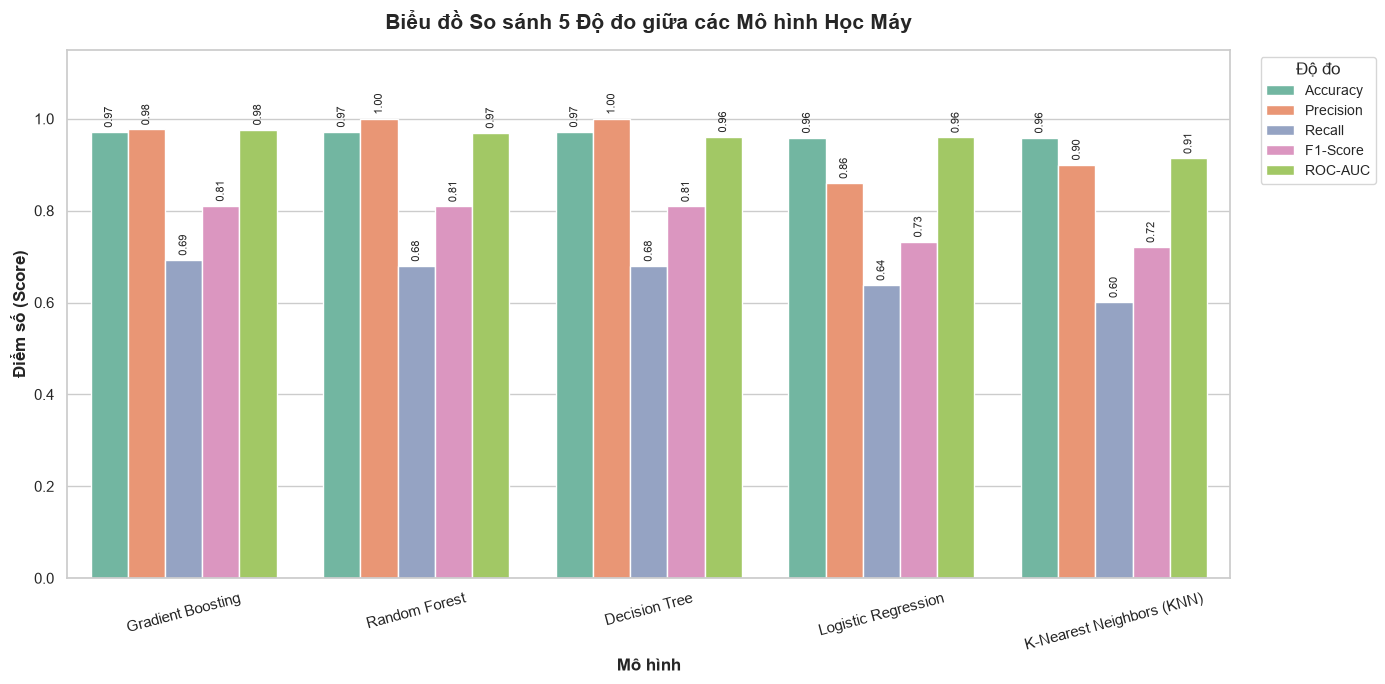


🏆 MÔ HÌNH TỐT NHẤT: Gradient Boosting
- Accuracy : 0.9714
- Precision: 0.9767
- Recall   : 0.6928
- F1-Score : 0.8106
- ROC-AUC  : 0.9765
📁 Đã xuất các file sẵn sàng cho Flask Backend:
 1. best_diabetes_model.pkl (Mô hình tốt nhất)
 2. scaler_diabetes.pkl     (Bộ chuẩn hóa StandardScaler)
 3. model_columns.json      (Danh sách các cột đặc trưng)


In [12]:
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hiển thị bảng tổng hợp kết quả
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
print("="*80)
print("📊 BẢNG TỔNG HỢP SO SÁNH 5 MÔ HÌNH VỚI 5 ĐỘ ĐO")
print("="*80)
print(df_results.to_string(index=False))

# 2. VẼ BIỂU ĐỒ CỘT SO SÁNH TRỰC QUAN CẢ 5 ĐỘ ĐO
# Biến đổi DataFrame sang dạng dài (melt) để vẽ biểu đồ nhóm với Seaborn
df_melted = pd.melt(
    df_results, 
    id_vars=['Model'], 
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

chart = sns.barplot(
    data=df_melted, 
    x='Model', 
    y='Score', 
    hue='Metric', 
    palette='Set2'
)

plt.title('Biểu đồ So sánh 5 Độ đo giữa các Mô hình Học Máy', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Mô hình', fontsize=12, fontweight='bold')
plt.ylabel('Điểm số (Score)', fontsize=12, fontweight='bold')
plt.ylim(0, 1.15)
plt.xticks(rotation=15, fontsize=11)
plt.legend(title='Độ đo', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

# Hiển thị số liệu chi tiết trên đỉnh từng cột
for p in chart.patches:
    height = p.get_height()
    if height > 0:
        chart.annotate(f"{height:.2f}",
                       (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='bottom', fontsize=8, rotation=90, xytext=(0, 3),
                       textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. CHỌN VÀ LƯU MÔ HÌNH TỐT NHẤT CÙNG CÁC TỆP CẤU HÌNH
best_model_name = df_results.iloc[0]['Model']
best_model_obj = trained_models[best_model_name]

# Lưu mô hình (.pkl)
joblib.dump(best_model_obj, 'best_diabetes_model.pkl')

# Lưu scaler (.pkl)
joblib.dump(scaler, 'scaler_diabetes.pkl')

# Lưu danh sách cột sau khi One-Hot Encoding (.json) để Flask tái tạo đúng ma trận đầu vào
with open('model_columns.json', 'w', encoding='utf-8') as f:
    json.dump(list(X.columns), f, ensure_ascii=False)

print("\n" + "="*80)
print(f"🏆 MÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f"- Accuracy : {df_results.iloc[0]['Accuracy']}")
print(f"- Precision: {df_results.iloc[0]['Precision']}")
print(f"- Recall   : {df_results.iloc[0]['Recall']}")
print(f"- F1-Score : {df_results.iloc[0]['F1-Score']}")
print(f"- ROC-AUC  : {df_results.iloc[0]['ROC-AUC']}")
print("="*80)
print("📁 Đã xuất các file sẵn sàng cho Flask Backend:")
print(" 1. best_diabetes_model.pkl (Mô hình tốt nhất)")
print(" 2. scaler_diabetes.pkl     (Bộ chuẩn hóa StandardScaler)")
print(" 3. model_columns.json      (Danh sách các cột đặc trưng)")
print("="*80)

## Bước 7: Khởi chạy Flask API kết nối Front-End

In [13]:
import threading
import json
import joblib
import pandas as pd
from flask import Flask, request, jsonify
from flask_cors import CORS

# 1. Khởi tạo ứng dụng Flask
app = Flask(__name__)
# Cho phép CORS để Front-End (React, Vue, HTML/JS) gọi API không bị lỗi chặn truy cập
CORS(app)

# 2. Tải mô hình tốt nhất, scaler và danh sách cột đặc trưng đã lưu ở cell trên
loaded_model = joblib.load('best_diabetes_model.pkl')
loaded_scaler = joblib.load('scaler_diabetes.pkl')
with open('model_columns.json', 'r', encoding='utf-8') as f:
    model_columns = json.load(f)

# Endpoint kiểm tra trạng thái hoạt động của server
@app.route('/', methods=['GET'])
def root():
    return jsonify({
        "status": "online",
        "message": "Flask API Diabetes Prediction đang chạy ngầm từ Notebook!"
    })

# Endpoint chính nhận dữ liệu từ Front-End và trả về kết quả dự đoán
@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Nhận dữ liệu JSON từ Front-End gửi lên
        data = request.get_json()
        if not data:
            return jsonify({"success": False, "message": "Không nhận được dữ liệu!"}), 400

        # Chuyển đổi dữ liệu input sang DataFrame
        input_df = pd.DataFrame([data])

        # Áp dụng One-Hot Encoding giống hệt quá trình huấn luyện
        input_df = pd.get_dummies(input_df, columns=['gender', 'smoking_history'], drop_first=True)

        # Căn chỉnh đầy đủ các cột (thiếu cột nào tự động bù 0)
        input_processed = input_df.reindex(columns=model_columns, fill_value=0)

        # Chuẩn hóa nếu mô hình tốt nhất là KNN hoặc Logistic Regression
        model_type = type(loaded_model).__name__
        if model_type in ["KNeighborsClassifier", "LogisticRegression", "SVC"]:
            features = loaded_scaler.transform(input_processed)
        else:
            features = input_processed

        # Thực hiện dự đoán
        prediction = int(loaded_model.predict(features)[0])
        
        # Tính xác suất mắc bệnh (%)
        if hasattr(loaded_model, "predict_proba"):
            probabilities = loaded_model.predict_proba(features)[0]
            risk_percentage = round(float(probabilities[1]) * 100, 2)
        else:
            risk_percentage = 100.0 if prediction == 1 else 0.0

        # Trả kết quả JSON về cho Front-End hiển thị
        return jsonify({
            "success": True,
            "prediction": prediction,
            "diagnosis": "Nguy cơ cao mắc tiểu đường (Dương tính)" if prediction == 1 else "Bình thường / Ít nguy cơ (Âm tính)",
            "risk_percentage": risk_percentage,
            "model_used": model_type
        })

    except Exception as e:
        return jsonify({"success": False, "error": str(e)}), 500

# 3. Chạy Server ở luồng ngầm (Daemon Thread) để không chiếm quyền điều khiển Notebook
def run_flask_app():
    app.run(host='127.0.0.1', port=5000, use_reloader=False)

flask_server_thread = threading.Thread(target=run_flask_app, daemon=True)
flask_server_thread.start()

print("="*70)
print("🚀 [BƯỚC 5] FLASK API ĐÃ KHỞI CHẠY THÀNH CÔNG!")
print("📍 API Endpoint: http://127.0.0.1:5000/predict")
print("🌐 Đã bật CORS - Front-End có thể gửi request POST ngay bây giờ.")
print("="*70)

🚀 [BƯỚC 5] FLASK API ĐÃ KHỞI CHẠY THÀNH CÔNG!
📍 API Endpoint: http://127.0.0.1:5000/predict
🌐 Đã bật CORS - Front-End có thể gửi request POST ngay bây giờ.
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
